# Task 6
#### 1. Using PermFIT on different classifiers 
#### 2. Using different clustering methods

## - Import everything needed

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## - Load the beat dataset

In [2]:
# load data
data = np.loadtxt('train_beats.csv', delimiter=',')
# x is feature, y is label(First 1000)
X = data[:, :-2]
#X = X[:1000]
y = data[:, -2].astype(int)
print(X.shape)
#load test data
t_data = np.loadtxt('test_beats.csv', delimiter=',')
x_test = t_data[:, :-2]
y_test = t_data[:, -2].astype(int)
print(x_test.shape)
print('data loaded successfully')

(30992, 275)
(37442, 275)
data loaded successfully


## - Using PermFIT on different classifiers on beats dataset

Find a better parameter for the classifier   
Using grid search to find the best combination in given parameters

## Random Forest Classifier

In [12]:
# define paragram grid
param_grid = {
    'n_estimators': [100, 200, 300],       # 森林中树的数量
    'max_depth': [10, 20, 30, None],       # 每棵树的最大深度
    'max_features': ['sqrt', 'log2'],      # 每次分裂考虑的特征数
    'min_samples_split': [2, 5, 10],       # 节点继续分裂的最小样本数
    'min_samples_leaf': [1, 2, 4]          # 叶子节点的最小样本数
}

# found model
rf = RandomForestClassifier(random_state=42)

# grid search
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

# output the best parameters combination
print("Best Parameters (RandomForest):", grid_search.best_params_)

# get the best model
best_rf = grid_search.best_estimator_

# prediction on the test set
y_pred = best_rf.predict(x_test)

# output the performance indicators
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred)) 

Best Parameters (RandomForest): {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Accuracy: 0.969819988248491
Precision: 0.9758854362837268
Recall: 0.969819988248491
F1 Score: 0.9717288155664224

Classification Report:
               precision    recall  f1-score   support

           1       1.00      0.97      0.98     28474
           2       0.99      1.00      0.99      1636
           3       0.99      0.99      0.99      2581
           4       0.77      0.96      0.86      1307
           5       0.65      0.89      0.75       783
           6       0.57      0.90      0.70       191
           7       0.85      0.93      0.89       416
           8       0.99      0.99      0.99      2054

    accuracy                           0.97     37442
   macro avg       0.85      0.95      0.89     37442
weighted avg       0.98      0.97      0.97     37442



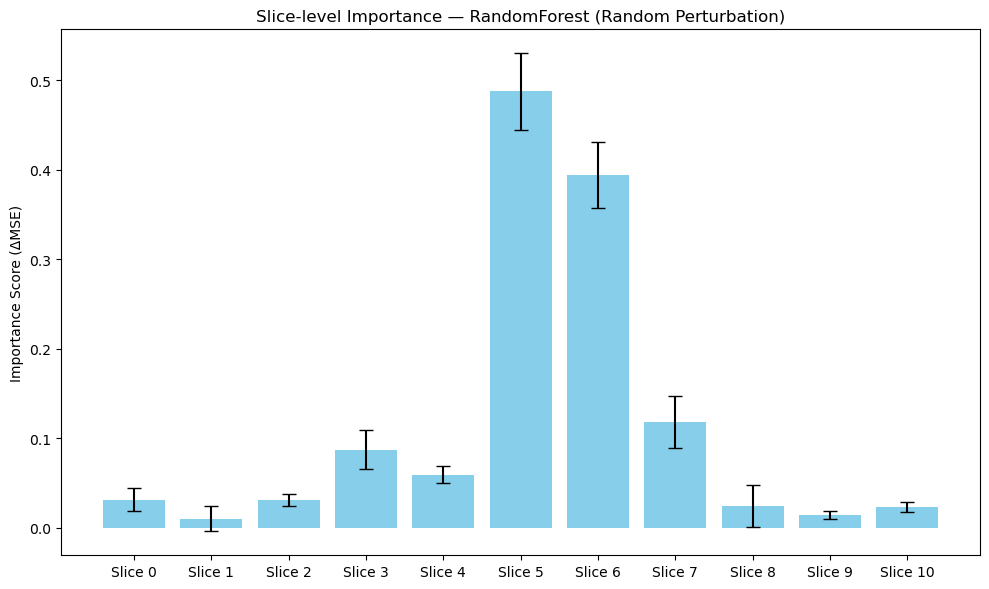

In [16]:
# Random Forest Classifier

# Parameters
num_features = X.shape[1]   # 275
num_slices = 11
slice_size = num_features // num_slices
slices = [range(i*slice_size, (i+1)*slice_size) for i in range(num_slices)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

importance_scores = np.zeros(num_slices)
variances = np.zeros(num_slices)
slice_fold_scores = [[] for _ in range(num_slices)]

# Cross-validation
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    clf = RandomForestClassifier(
        n_estimators=300,       
        max_depth=20,           
        max_features='log2',    
        min_samples_split=2,    
        min_samples_leaf=1,     
        random_state=42
    )
    clf.fit(X_train, y_train)

    y_pred_orig = clf.predict(X_val)
    mse_orig = np.mean((y_val - y_pred_orig)**2)

    # Random perturbation for each slice
    for s_idx, s in enumerate(slices):
        X_val_perturbed = X_val.copy()
        for col in s:
            np.random.shuffle(X_val_perturbed[:, col])

        y_pred_perturbed = clf.predict(X_val_perturbed)
        mse_perturbed = np.mean((y_val - y_pred_perturbed)**2)
        delta_mse = mse_perturbed - mse_orig
        slice_fold_scores[s_idx].append(delta_mse)

# Compute mean importance and variance
for s_idx in range(num_slices):
    importance_scores[s_idx] = np.mean(slice_fold_scores[s_idx])
    variances[s_idx] = np.var(slice_fold_scores[s_idx])

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(range(num_slices), importance_scores, yerr=np.sqrt(variances), capsize=5, color='skyblue')
plt.xticks(range(num_slices), [f"Slice {i}" for i in range(num_slices)])
plt.ylabel("Importance Score (ΔMSE)")
plt.title("Slice-level Importance — RandomForest (Random Perturbation)")
plt.tight_layout()
plt.show()


## - Using Logistic Regression

Find a better parameter for the classifier   
Using grid search to find the best combination in given parameters

In [22]:
# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],          # Regularization strength
    'penalty': ['l1', 'l2'],               # Type of regularization
    'solver': ['liblinear', 'saga']        # Optimizers that support l1/l2
}

# Build model
log_reg = LogisticRegression(max_iter=5000, random_state=42)

# Grid search
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X[:2000], y[:2000])

# Best model  
best_log_reg = grid_search.best_estimator_
print("Best Parameters (Logistic Regression):", grid_search.best_params_)

# Evaluate on test set
y_pred = best_log_reg.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Best Parameters (Logistic Regression): {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Accuracy: 0.6539447679076973
Precision: 0.8807037397105008
Recall: 0.6539447679076973
F1 Score: 0.7141015517716318

Classification Report:
               precision    recall  f1-score   support

           1       0.98      0.58      0.73     28474
           2       0.53      0.96      0.69      1636
           3       0.72      0.88      0.80      2581
           4       0.30      0.76      0.43      1307
           5       0.11      0.67      0.18       783
           6       0.08      0.86      0.14       191
           7       0.19      0.74      0.31       416
           8       0.81      0.97      0.88      2054

    accuracy                           0.65     37442
   macro avg       0.47      0.80      0.52     37442
weighted avg       0.88      0.65      0.71     37442



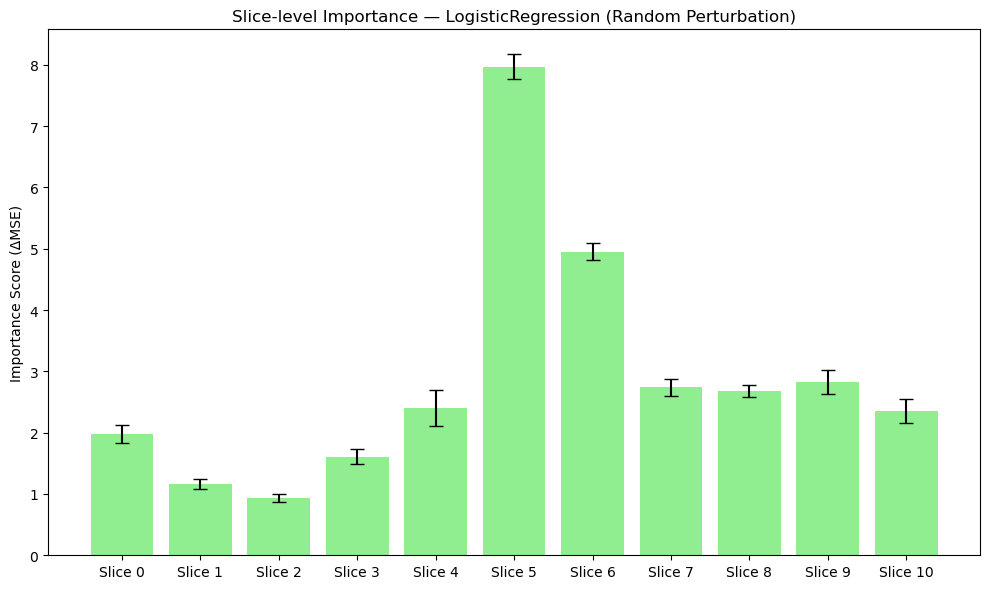

In [23]:
# Parameters
num_features = X.shape[1]   # 275
num_slices = 11
slice_size = num_features // num_slices
slices = [range(i*slice_size, (i+1)*slice_size) for i in range(num_slices)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

importance_scores = np.zeros(num_slices)
variances = np.zeros(num_slices)
slice_fold_scores = [[] for _ in range(num_slices)]

# Cross-validation
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    clf = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C = 1.0,
        penalty = 'l2',
        solver = 'saga'
    )
    clf.fit(X_train, y_train)

    y_pred_orig = clf.predict(X_val)
    mse_orig = np.mean((y_val - y_pred_orig)**2)

    # Random perturbation for each slice
    for s_idx, s in enumerate(slices):
        X_val_perturbed = X_val.copy()
        for col in s:
            np.random.shuffle(X_val_perturbed[:, col])

        y_pred_perturbed = clf.predict(X_val_perturbed)
        mse_perturbed = np.mean((y_val - y_pred_perturbed)**2)
        delta_mse = mse_perturbed - mse_orig
        slice_fold_scores[s_idx].append(delta_mse)

# Compute mean importance and variance
for s_idx in range(num_slices):
    importance_scores[s_idx] = np.mean(slice_fold_scores[s_idx])
    variances[s_idx] = np.var(slice_fold_scores[s_idx])

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(range(num_slices), importance_scores, yerr=np.sqrt(variances), capsize=5, color='lightgreen')
plt.xticks(range(num_slices), [f"Slice {i}" for i in range(num_slices)])
plt.ylabel("Importance Score (ΔMSE)")
plt.title("Slice-level Importance — LogisticRegression (Random Perturbation)")
plt.tight_layout()
plt.show()

## - Using MLPClassifier

Find a better parameter for the classifier   
Using grid search to find the best combination in given parameters

In [15]:
# Define parameter grid
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (128,64), (256,128)],  # Hidden layer structures
    'activation': ['relu', 'tanh', 'logistic'],                  # Activation functions
    'solver': ['adam', 'sgd'],                                   # Optimizers
    'alpha': [0.0001, 0.001, 0.01],                              # L2 regularization parameter
    'learning_rate': ['constant', 'adaptive']                    # Learning rate strategies
}

# Build model
mlp = MLPClassifier(max_iter=500, random_state=42)

# Grid search
grid_search = GridSearchCV(mlp, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X[:2000], y[:2000])

# Best model
best_mlp = grid_search.best_estimator_
print("Best Parameters (MLPClassifier):", grid_search.best_params_)

# Evaluate on test set
y_pred = best_mlp.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted')) 
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Best Parameters (MLPClassifier): {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (128,), 'learning_rate': 'constant', 'solver': 'adam'}
Accuracy: 0.8632017520431601
Precision: 0.9407685798621026
Recall: 0.8632017520431601
F1 Score: 0.8892885738926921

Classification Report:
               precision    recall  f1-score   support

           1       0.99      0.83      0.91     28474
           2       0.95      0.99      0.97      1636
           3       0.84      0.95      0.89      2581
           4       0.57      0.93      0.71      1307
           5       0.30      0.87      0.44       783
           6       0.12      0.91      0.21       191
           7       0.41      0.92      0.57       416
           8       0.98      0.99      0.98      2054

    accuracy                           0.86     37442
   macro avg       0.65      0.92      0.71     37442
weighted avg       0.94      0.86      0.89     37442



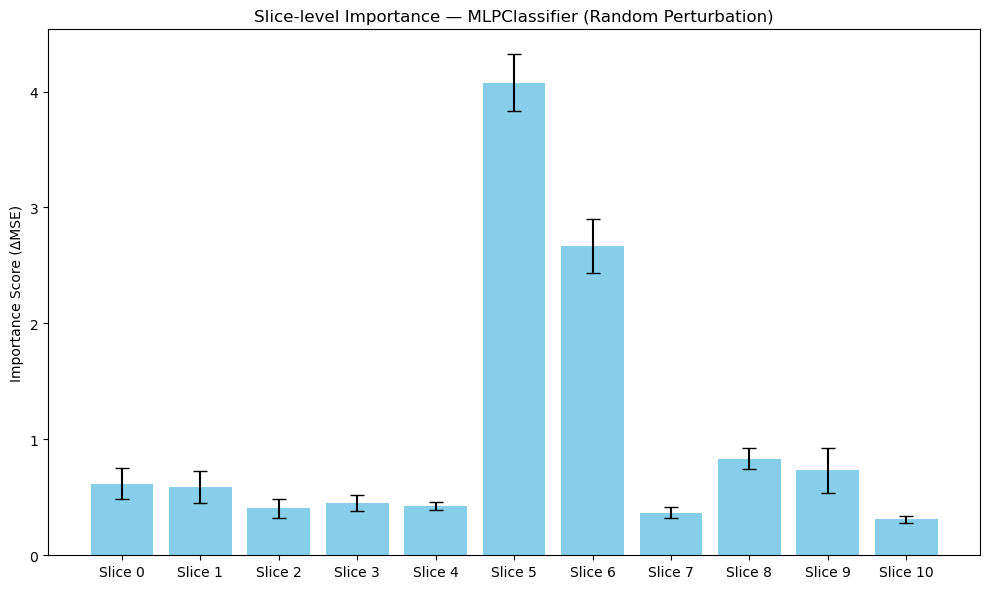

In [3]:
# Parameters
num_features = X.shape[1]   # 275
num_slices = 11
slice_size = num_features // num_slices
slices = [range(i*slice_size, (i+1)*slice_size) for i in range(num_slices)]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

importance_scores = np.zeros(num_slices)
variances = np.zeros(num_slices)
slice_fold_scores = [[] for _ in range(num_slices)]

# Cross-validation
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Train MLP
    clf = MLPClassifier(hidden_layer_sizes=(128, ), 
                        activation='relu',
                        alpha=0.01,
                        solver='adam', 
                        max_iter=500, 
                        learning_rate='constant',
                        random_state=42)
    clf.fit(X_train, y_train)

    y_pred_orig = clf.predict(X_val)
    mse_orig = np.mean((y_val - y_pred_orig)**2)

    # Random perturbation for each slice
    for s_idx, s in enumerate(slices):
        X_val_perturbed = X_val.copy()
        for col in s:
            np.random.shuffle(X_val_perturbed[:, col])  # shuffle each feature in slice

        y_pred_perturbed = clf.predict(X_val_perturbed)
        mse_perturbed = np.mean((y_val - y_pred_perturbed)**2)
        delta_mse = mse_perturbed - mse_orig
        slice_fold_scores[s_idx].append(delta_mse)

# Compute mean importance and variance
for s_idx in range(num_slices):
    importance_scores[s_idx] = np.mean(slice_fold_scores[s_idx])
    variances[s_idx] = np.var(slice_fold_scores[s_idx])

# Visualization
plt.figure(figsize=(10, 6))
plt.bar(range(num_slices), importance_scores, yerr=np.sqrt(variances), capsize=5, color='skyblue')
plt.xticks(range(num_slices), [f"Slice {i}" for i in range(num_slices)])
plt.ylabel("Importance Score (ΔMSE)")
plt.title("Slice-level Importance — MLPClassifier (Random Perturbation)")
plt.tight_layout()

## Clustering the beat dataset

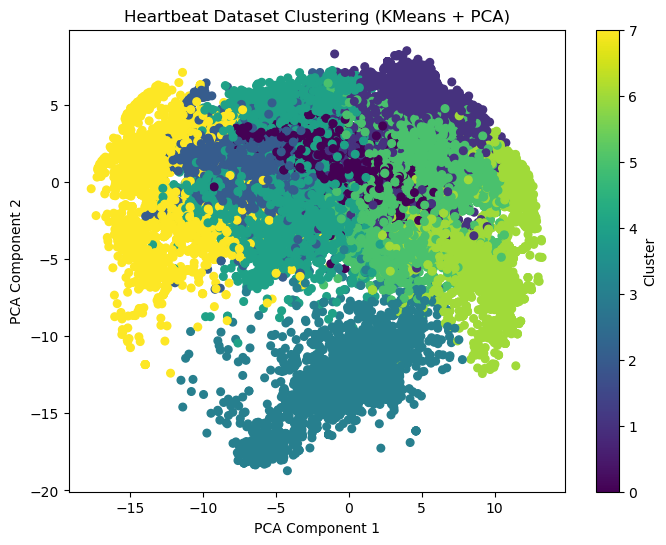

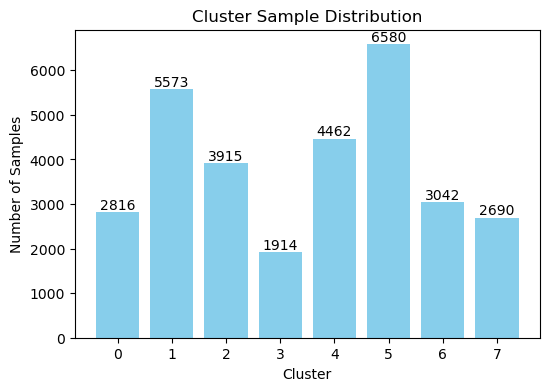

In [11]:
# Generate the cores number of CPU
os.environ["LOKY_MAX_CPU_COUNT"] = "24"

# Define KMeans model
kmeans = KMeans(n_clusters=8, random_state=42)  # Cluster into 3 groups
kmeans.fit(X)

# Get cluster labels
labels = kmeans.labels_

# Visualization (reduce to 2D using PCA)
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=labels, cmap='viridis', s=30)
plt.title("Heartbeat Dataset Clustering (KMeans + PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

# Output number of samples in each cluster
unique, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(6,4))
bars = plt.bar(unique, counts, color='skyblue')

# Add sample count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height(), 
             str(count), 
             ha='center', va='bottom', fontsize=10)

plt.xlabel("Cluster")
plt.ylabel("Number of Samples")
plt.title("Cluster Sample Distribution")
plt.xticks(unique)
plt.show()